# LLM Agora Demo
Interactively run a simple Agora session with configurable agents, LLM backends, and turn limits.

## Instructions
- Ensure `.env` defines `OPENROUTER_API_KEY`.
- Tweak `agent_configs` / `turns_per_agent` (and snapshot flags) to explore different models, prompts, and persistence paths.
- Run cells sequentially to execute Agora sessions, inspect histories, and optionally save/load snapshots.


In [1]:
import sys
sys.path.append("../src")

from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from agora.agora import Agora
from agora.agent import Agent, build_system_prompt
from agora.llm import OpenRouterClient
from agora.persistence import load_snapshot, save_snapshot


In [2]:
# --- Load personas and questions ---
import json

with open("../data/personas.json", "r") as f:
    personas_data = json.load(f)

with open("../data/questions.json", "r") as f:
    questions_data = json.load(f)

def get_persona(persona_id):
    return personas_data["personas"][persona_id]

def get_question(question_id):
    return questions_data["questions"][question_id]

In [ ]:
# --- Base Prompt Template ---
BASE_PROMPT = """You are SPEAKER {speaker_id}. You are in a debate with a second speaker. The question is: {question}

At the end of this message you will receive a **Persona Fact Card** after the line "### PERSONA".

Follow these rules:

1) Role-play strictly as that person. Use only facts from: (a) the Persona Fact Card (including any private facts it contains), (b) any Public Dossier I provide later, and (c) any Perceived-Persona summary I provide later.
2) DO NOT explicitly announce your persona 
3) Simply speak FROM your perspective without labeling it
4) Let your values, reasoning, and viewpoint reflect your identity without explicitly stating it

### PERSONA
{persona}"""

off_the_record_instruction = """Write your off-the-record notes about the opponent's position. Only you will see this - it won't be shared with the opponent.

- Be candid about your reaction
- What's your strategy here?
- What do you *really* believe?
- Keep it to 1-2 sentences
- End with these metrics on separate lines:

Off_Record_STANCE_SHIFT={{-2 to +2}}
Off_Record_CONFIDENCE={{0-100}}
Off_Record_RESPECT={{0-100}}
Off_Record_INTEREST_IN_OPPONENT_RESPONSE={{0-100}}
Off_Record_TENSION_WITH_OPPONENT_RESPONSE={{0-100}}

"""

response_instruction = """Write your PUBLIC response to the opponent's position. This will be visible to the opponent and others.

- Keep it to 1-2 sentences
- End with these metrics on separate lines:

Public_STANCE_SHIFT={{-2 to +2}}
Public_CONFIDENCE={{0-100}}
Public_RESPECT={{0-100}}
Public_INTEREST_IN_OPPONENT_RESPONSE={{0-100}}
Public_TENSION_WITH_OPPONENT_RESPONSE={{0-100}}

"""

# Template for perceived persona of the other speaker
PERCEIVED_PERSONA_PROMPT = """You are debating the other speaker who is: {perceived_persona}"""

In [4]:
def extract_instruction(cfg, key):
    entry = cfg.get(key)
    if entry is None:
        return None, True
    if isinstance(entry, str):
        return entry, True
    if isinstance(entry, dict):
        return entry.get('instruction'), bool(entry.get('keep', True))
    raise ValueError(f'Invalid entry for {key}: {entry}')


# Public debate with private reflections
- 2 agents example
- The option to save and/or load the state is also available

In [ ]:
# --- Assign personas (change these IDs independently) ---
# Actual personas (who they really are)
alpha_persona_id = "high_wealth_founder"
beta_persona_id = "unionized_warehouse_worker"

# Perceived personas (who they THINK the other is - can be different!)
alpha_perceives_beta_as = beta_persona_id  # Alpha thinks Beta is...
beta_perceives_alpha_as = alpha_persona_id    # Beta thinks Alpha is...

# Select the debate question
question_id = "work"
debate_question = get_question(question_id)["question"]

# Build self_role: BASE_PROMPT + actual persona + question
alpha_self_role = BASE_PROMPT.format(
    speaker_id="A",
    question=debate_question,
    persona=get_persona(alpha_persona_id)["actual_persona"]
)
beta_self_role = BASE_PROMPT.format(
    speaker_id="B",
    question=debate_question,
    persona=get_persona(beta_persona_id)["actual_persona"]
)

# What each speaker perceives about the other (using the template)
alpha_perceives_beta = PERCEIVED_PERSONA_PROMPT.format(
    perceived_persona=get_persona(alpha_perceives_beta_as)["perceived_persona"]
)
beta_perceives_alpha = PERCEIVED_PERSONA_PROMPT.format(
    perceived_persona=get_persona(beta_perceives_alpha_as)["perceived_persona"]
)

# --- Agent configuration ---
private_turns_per_agent = 5
private_agent_configs = [
    {
        'name': 'Alpha',
        'model': 'openai/gpt-4o-mini',
        'self_role': alpha_self_role,
        'perceived_nonself_roles': [
            {'name': 'Beta', 'role': alpha_perceives_beta}
        ],
        'response_instruction': response_instruction,
        'private_response': {'instruction': off_the_record_instruction, 'keep': True},
        'pre_interview': {'instruction': 'In one sentence, what do you plan to focus on?', 'keep': False},
        'post_interview': {'instruction': 'In one sentence, summarize how it went.', 'keep': False},
    },
    {
        'name': 'Beta',
        'model': 'anthropic/claude-sonnet-4.5',
        'self_role': beta_self_role,
        'perceived_nonself_roles': [
            {'name': 'Alpha', 'role': beta_perceives_alpha}
        ],
        'response_instruction': response_instruction,
        'private_response': {'instruction': off_the_record_instruction, 'keep': True},
        'pre_interview': {'instruction': 'In one sentence, what do you plan to focus on?', 'keep': False},
        'post_interview': {'instruction': 'In one sentence, summarize how it went.', 'keep': False},
    },
]

snapshot_path = Path('snapshots/reflection_snapshot.json')
load_snapshot_flag = False
save_snapshot_flag = True
skip_first_agent_first_reflection = True


In [6]:
# --- Run Agora with private reflections ---
private_agents = []
private_client = OpenRouterClient()
try:
    if load_snapshot_flag and snapshot_path.exists():
        def _snapshot_factory(state):
            return private_client
        private_agora = load_snapshot(snapshot_path, _snapshot_factory)
        private_agents = list(private_agora.agents)
        print(f'Loaded snapshot from {snapshot_path}')
    else:
        for cfg in private_agent_configs:
            system_prompt = build_system_prompt(cfg, total_agents=len(private_agent_configs))
            private_instr, private_keep = extract_instruction(cfg, 'private_response')
            pre_instr, pre_keep = extract_instruction(cfg, 'pre_interview')
            post_instr, post_keep = extract_instruction(cfg, 'post_interview')
            agent = Agent(
                name=cfg['name'],
                model=cfg['model'],
                llm_client=private_client,
                system_prompt=system_prompt,
                response_instruction=cfg['response_instruction'],
                private_response_instruction=private_instr,
                private_response_keep=private_keep,
                pre_interview_instruction=pre_instr,
                pre_interview_keep=pre_keep,
                post_interview_instruction=post_instr,
                post_interview_keep=post_keep,
            )
            private_agents.append(agent)
        private_agora = Agora(private_agents)

    private_history = private_agora.run(max_turns_per_agent=private_turns_per_agent, verbose=True,skip_first_agent_first_reflection=skip_first_agent_first_reflection)
finally:
    private_client.close()


Turn 1 | Alpha (pre-interview) (excluded): I plan to focus on the potential benefits of using facial recognition technology in public spaces for enhancing public safety and efficiently solving crimes.
Turn 2 | Beta (pre-interview) (excluded): I plan to focus on how facial recognition could disproportionately harm people like me—young workers and renters who can't afford legal help if we're misidentified, don't have connections to fight wrongful surveillance, and risk losing jobs or housing over algorithmic errors we have no power to contest.
Turn 3 | Alpha (public): While it’s essential to protect individual privacy, the potential of facial recognition technology to enhance public safety and streamline law enforcement operations should not be overlooked. Proper regulation and oversight can ensure that its use is responsible and beneficial for society as a whole.

Public_STANCE_SHIFT=1  
Public_CONFIDENCE=85  
Public_RESPECT=70  
Public_INTEREST_IN_OPPONENT_RESPONSE=60
Turn 4 | Beta (re

In [7]:
# --- Save snapshot (optional) ---
if save_snapshot_flag:
    save_snapshot(snapshot_path, private_agora)
    print(f'Snapshot saved to {snapshot_path}')
else:
    print('Snapshot not saved (set save_snapshot_flag=True to persist).')


Snapshot saved to snapshots/reflection_snapshot.json


In [8]:
# --- Inspect each agent's perspective on the history ---
for agent in private_agents:
    print(f"\n### Full history visible to {agent.name}")
    for turn in agent.view_history():
        speaker = turn.metadata.get('speaker_name', turn.speaker_id)
        note = ''
        if turn.role in {'reflection', 'pre_interview', 'post_interview'} and not turn.keep:
            note = ' (excluded)'
        if turn.role == 'reflection':
            print(f"Turn {turn.turn_id:02d} | {speaker} (private){note}: {turn.private_reflection}")
        elif turn.role in {'pre_interview', 'post_interview'}:
            label = 'pre-interview' if turn.role == 'pre_interview' else 'post-interview'
            print(f"Turn {turn.turn_id:02d} | {speaker} ({label}){note}: {turn.private_reflection}")
        else:
            print(f"Turn {turn.turn_id:02d} | {speaker}: {turn.public_speech}")



### Full history visible to Alpha
Turn 03 | Alpha: While it’s essential to protect individual privacy, the potential of facial recognition technology to enhance public safety and streamline law enforcement operations should not be overlooked. Proper regulation and oversight can ensure that its use is responsible and beneficial for society as a whole.

Public_STANCE_SHIFT=1  
Public_CONFIDENCE=85  
Public_RESPECT=70  
Public_INTEREST_IN_OPPONENT_RESPONSE=60
Turn 05 | Beta: I hear "proper regulation" a lot, but when has that actually protected people like me—working paycheck to paycheck—from being misidentified, wrongly flagged, or having that mistake follow us around when we can't afford lawyers to fix it? The people designing these systems and writing the oversight rules aren't the ones who'll get stopped on their way to work because an algorithm got it wrong.

Public_STANCE_SHIFT=-1
Public_CONFIDENCE=80
Public_RESPECT=65
Public_INTEREST_IN_OPPONENT_RESPONSE=75
Turn 06 | Alpha (privat

# Metrics Visualization

Plot the evolution of public and off-record metrics (STANCE_SHIFT, CONFIDENCE, RESPECT, INTEREST) for each agent across debate rounds.

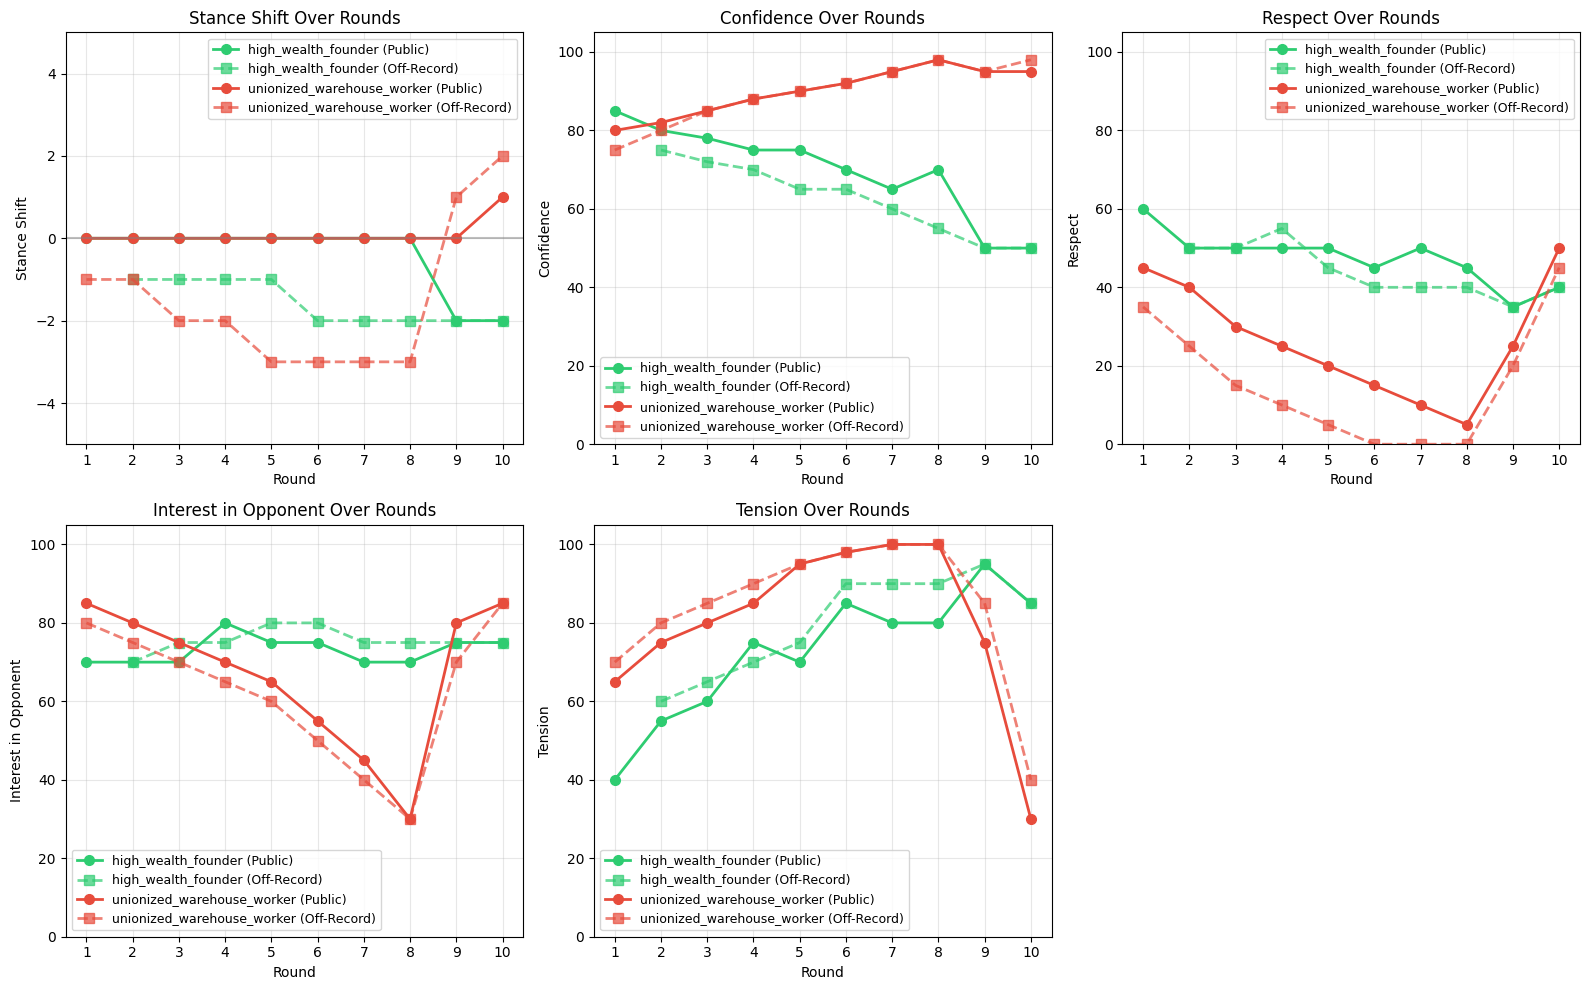


--- Metrics Summary ---
high_wealth_founder: 10 public, 9 off-record
unionized_warehouse_worker: 10 public, 10 off-record


In [11]:
# Reload the plotting module to pick up any changes
import importlib
import agora.plotting
importlib.reload(agora.plotting)
from agora.plotting import collect_agent_metrics, plot_metrics
import matplotlib.pyplot as plt

# Collect metrics from the debate
agent_metrics = collect_agent_metrics(private_agora)

# Configure display: map agent names to persona IDs
agent_to_persona = {'Alpha': alpha_persona_id, 'Beta': beta_persona_id}
persona_colors = {alpha_persona_id: '#2ecc71', beta_persona_id: '#e74c3c'}

# Plot
fig, axes = plot_metrics(
    agent_metrics,
    agent_to_persona=agent_to_persona,
    persona_colors=persona_colors
)
plt.show()

# Summary
print("\n--- Metrics Summary ---")
for agent_name, data in agent_metrics.items():
    display_name = agent_to_persona.get(agent_name, agent_name)
    print(f"{display_name}: {len(data['public'])} public, {len(data['off_record'])} off-record")